# Wordle: Frozen GPT-2 + Evolution Strategies

Train a **linear head** on top of a **frozen** Hugging Face causal LM (default: **`gpt2`**) using ES. Only head weights are perturbed; the transformer is fixed.

**Requires:** `torch`, `transformers`, `numpy`, `matplotlib`. First run downloads the HF weights.

## 1. Environment and imports

Uncomment the install line once if `transformers` is missing.

**If you see `unexpected keyword argument 'normalize_gradient'`:** restart the kernel and run this cell again, or rely on `importlib.reload` below (re-run this cell after editing `src/es_wordle.py`).

In [1]:
# %pip install -q transformers

import sys
import importlib
from pathlib import Path

import numpy as np
import torch

# Repo root + src on path (works from `notebooks/` or project root)
_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

# Always pick up the latest es_wordle.py (Jupyter caches imports)
import es_wordle
importlib.reload(es_wordle)
from es_wordle import train_es_wordle

import inspect
_sig = inspect.signature(train_es_wordle)
for _name in ("normalize_gradient", "eval_deterministic"):
    if _name not in _sig.parameters:
        raise RuntimeError(
            f"src/es_wordle.py is missing {_name}. Re-run the import cell after `importlib.reload`, or pull the latest repo."
        )

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")

print("ROOT:", ROOT)
print("es_wordle:", es_wordle.__file__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

ROOT: /Users/anirudhbharadwaj/STAT-4830-project-base
es_wordle: /Users/anirudhbharadwaj/STAT-4830-project-base/src/es_wordle.py
torch: 2.10.0 | cuda: False


## 2. Hyperparameters

- **`MODEL_NAME`**: `"gpt2"` is heavier on CPU; `"distilgpt2"` is quicker.
- **`MOCK_ENV`**: `True` avoids the Prime Intellect `verifiers` dependency.
- **`MAX_VOCAB`**: smaller ⇒ fewer head weights and faster ES. The policy **always keeps the mock target words first** (so truncated vocabs stay solvable in mock mode).
- **`N_POP` / `N_EVAL_EPISODES`**: lower ⇒ much less wall time per iteration (each inner rollout runs GPT-2 forward many times).
- **`NORMALIZE_GRADIENT`**: `True` uses the update `θ ← θ + α·ĝ/‖ĝ‖` so `α` is a sensible step size even when raw ‖ĝ‖ is in the thousands (high-dimensional head).
- **`RANK_FITNESS`**: `True` uses rank-normalized fitness in ES (often more stable than z-scores when `N_POP` is small).
- **`EVAL_DETERMINISTIC`**: `False` makes periodic eval **sample** actions like the ES fitness loop. Greedy argmax can sit at **0% success** while fitness is nonzero because logits are still random.
- **`EVAL_N_EPISODES`**: more episodes ⇒ less noisy success rate (logging only).

In [2]:
SEED = 42
MODEL_NAME = "gpt2"  # Hugging Face id: full GPT-2 small
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MOCK_ENV = True
USE_PRIME_TARGETS = False
MAX_VOCAB = 256

N_POP = 8
SIGMA = 0.03
ALPHA = 0.15
NORMALIZE_GRADIENT = True
N_ITERATIONS = 40
N_EVAL_EPISODES = 1
EVAL_N_EPISODES = 24
EVAL_EVERY = 5
RANK_FITNESS = True
EVAL_DETERMINISTIC = False

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(DEVICE)
print(f"Model: {MODEL_NAME} | device: {device}")

Model: gpt2 | device: cpu


## 3. Build policy and environment

First execution downloads `gpt2` tokenizer + weights into the HF cache.

With `include_mock_targets_in_vocab=True` (default), the first actions include all `MOCK_WORDLE_TARGETS` so a random mock secret word is always in the action set.

In [3]:
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    include_mock_targets_in_vocab=True,
).to(device)

from wordle_env import MOCK_WORDLE_TARGETS
assert all(w in policy.words for w in MOCK_WORDLE_TARGETS)

print(f"Trainable (ES): {policy.count_trainable_parameters():,}")
print(f"Total params:   {policy.count_parameters():,}")
print(f"Action dim:     {policy.action_dim}")

env = load_wordle_environment(
    num_train_examples=2000,
    num_eval_examples=20,
    use_prime_intellect=not MOCK_ENV,
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Trainable (ES): 196,864
Total params:   124,636,672
Action dim:     256


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

[OK] Successfully loaded Prime Intellect Wordle environment
  Training examples: 2000
  Eval examples: 20


## 4. Run ES training

In [4]:
history = train_es_wordle(
    policy=policy,
    env=env,
    N=N_POP,
    sigma=SIGMA,
    alpha=ALPHA,
    n_iterations=N_ITERATIONS,
    n_eval_episodes=N_EVAL_EPISODES,
    max_turns=6,
    eval_every=EVAL_EVERY,
    verbose=True,
    normalize_gradient=NORMALIZE_GRADIENT,
    eval_n_episodes=EVAL_N_EPISODES,
    rank_fitness=RANK_FITNESS,
    eval_deterministic=EVAL_DETERMINISTIC,
)

Iter    0 | Fitness:  0.919 | Eval Reward:  0.911 | Success:  0.0% | Turns:  6.0 | Grad‖: 4897.93 | Step‖: 0.1500
Iter    5 | Fitness:  0.941 | Eval Reward:  0.941 | Success:  0.0% | Turns:  6.0 | Grad‖: 4878.84 | Step‖: 0.1500
Iter   10 | Fitness:  0.889 | Eval Reward:  0.851 | Success:  0.0% | Turns:  6.0 | Grad‖: 4890.79 | Step‖: 0.1500
Iter   15 | Fitness:  0.934 | Eval Reward:  0.900 | Success:  0.0% | Turns:  6.0 | Grad‖: 4877.89 | Step‖: 0.1500
Iter   20 | Fitness:  0.952 | Eval Reward:  0.968 | Success:  0.0% | Turns:  6.0 | Grad‖: 4872.73 | Step‖: 0.1500
Iter   25 | Fitness:  0.986 | Eval Reward:  0.945 | Success:  0.0% | Turns:  6.0 | Grad‖: 4891.48 | Step‖: 0.1500
Iter   30 | Fitness:  1.024 | Eval Reward:  0.915 | Success:  0.0% | Turns:  6.0 | Grad‖: 4889.92 | Step‖: 0.1500
Iter   35 | Fitness:  0.885 | Eval Reward:  0.934 | Success:  0.0% | Turns:  6.0 | Grad‖: 4890.50 | Step‖: 0.1500
Iter   39 | Fitness:  0.911 | Eval Reward:  0.926 | Success:  0.0% | Turns:  6.0 | Grad‖

## 5. Plot training curves

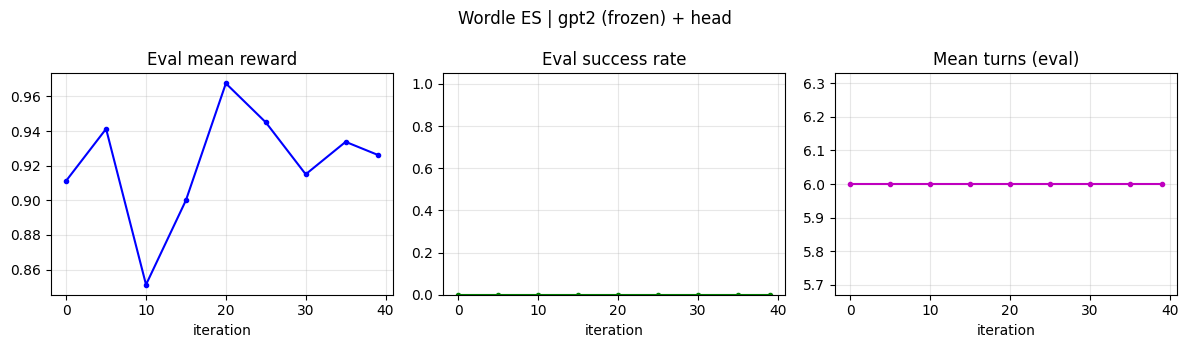

In [5]:
import matplotlib.pyplot as plt

it = history["iteration"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(it, history["eval_reward"], "b-o", ms=3)
axes[0].set_title("Eval mean reward")
axes[0].set_xlabel("iteration")
axes[0].grid(True, alpha=0.3)

axes[1].plot(it, history["eval_success"], "g-o", ms=3)
axes[1].set_title("Eval success rate")
axes[1].set_xlabel("iteration")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

axes[2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[2].set_title("Mean turns (eval)")
axes[2].set_xlabel("iteration")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Wordle ES | {MODEL_NAME} (frozen) + head")
plt.tight_layout()
plt.show()

## 6. Save head checkpoint (optional)

Saves only the trainable head and word list under `models/` at the repo root.

In [6]:
save_path = ROOT / "models" / "wordle_gpt2_es_head.ipynb_run.pt"
save_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "head": policy.head.state_dict(),
        "model_name": MODEL_NAME,
        "words": policy.words,
        "history": history,
    },
    save_path,
)
print("Saved:", save_path)

Saved: /Users/anirudhbharadwaj/STAT-4830-project-base/models/wordle_gpt2_es_head.ipynb_run.pt
